<a href="https://colab.research.google.com/github/mgb1112/Data-Science-For-Public-Health/blob/main/HW7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 7

**Group Members: Julia Martin, Grace Brooks, Keran W. chamberlin**



Return an ipython notebook and python streamlit app with the following:

0. Write a python function that takes an X and Y vector and returns an estimated $\beta_0$ and $\beta_1$ from linear regression. Check your function versus one of the prewritten ones. Include this in code cells of your ipython notebook.




In [ ]:
import numpy as np
import scipy.stats
from sklearn.linear_model import LinearRegression

def simple_linear_regression(X, Y):
    X = np.array(X)
    Y = np.array(Y)

    # Compute means
    X_mean = np.mean(X)
    Y_mean = np.mean(Y)

    # Compute beta1 (slope)
    beta1 = np.sum((X - X_mean) * (Y - Y_mean)) / np.sum((X - X_mean) ** 2)

    # Compute beta0 (intercept)
    beta0 = Y_mean - beta1 * X_mean

    return beta0, beta1

# Test function against scipy and sklearn
X_test = [1, 2, 3, 4, 5]
Y_test = [2, 3, 5, 4, 6]

# Using custom function
beta0, beta1 = simple_linear_regression(X_test, Y_test)
print(f"Custom function: beta0 = {beta0:.4f}, beta1 = {beta1:.4f}")

# Using scipy
slope, intercept, _, _, _ = scipy.stats.linregress(X_test, Y_test)
print(f"Scipy: beta0 = {intercept:.4f}, beta1 = {slope:.4f}")

# Using sklearn
X_test_reshaped = np.array(X_test).reshape(-1, 1)  # Reshape for sklearn
model = LinearRegression().fit(X_test_reshaped, Y_test)
sklearn_intercept = model.intercept_
sklearn_slope = model.coef_[0]
print(f"Sklearn: beta0 = {sklearn_intercept:.4f}, beta1 = {sklearn_slope:.4f}")

Custom function: beta0 = 1.3000, beta1 = 0.9000
Scipy: beta0 = 1.3000, beta1 = 0.9000
Sklearn: beta0 = 1.3000, beta1 = 0.9000


We used numpy to create a function that takes in X and Y inputs, then calculates the mean, slope, and intercept in a linear regression sense and returns the beta0 and beta1 values. We then tested two different python linear regression options (scipy and sklearn) and our function with the same inputs and found that we end up with the same returned beta values.

1. Using Python and basic numpy functions, fit a linear regression model to the kirby 21 dataset into colab for the left telencelphalon (predictor) to the right telencephalon (outcome). Also, do the same reversing the predictor and response relationship. Do a scatterplot of the left telencephalon (type 1 level 1) volume by the right. Do not hold out any data (there's only 21 observations).


https://raw.githubusercontent.com/smart-stats/ds4bio_book/refs/heads/main/book/assetts/kirby21.csv

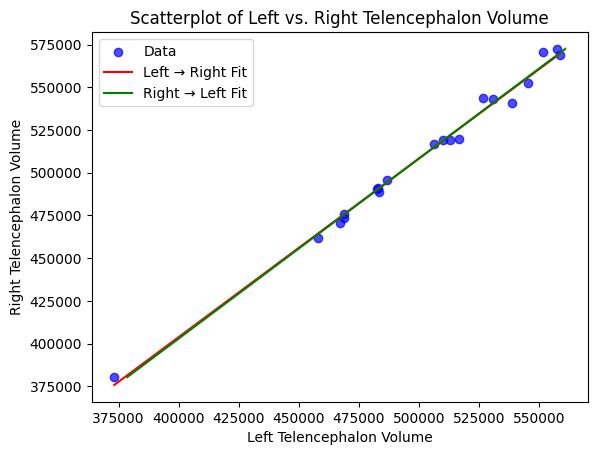

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# load the dataset from github
url = "https://raw.githubusercontent.com/smart-stats/ds4bio_book/refs/heads/main/book/assetts/kirby21.csv"
df = pd.read_csv(url)

# extract relevant columns (telencephalon data)
left_tel = df.loc[df['roi'] == "Telencephalon_L", 'volume'].values
right_tel = df.loc[df['roi'] == "Telencephalon_R", 'volume'].values

# define function for simple linear regression using NumPy
def linear_regression(X, Y):
    X = np.column_stack((np.ones(len(X)), X))  # add intercept
    beta = np.linalg.inv(X.T @ X) @ X.T @ Y  # compute coefficients
    return beta

# fit left predicts right model
beta_left_to_right = linear_regression(left_tel, right_tel)

# fit right predicts left model
beta_right_to_left = linear_regression(right_tel, left_tel)

# create a scatterplot of left vs. right telencephalon volumes
plt.scatter(left_tel, right_tel, color='blue', alpha=0.7, label="Data")
plt.xlabel("Left Telencephalon Volume")
plt.ylabel("Right Telencephalon Volume")
plt.title("Scatterplot of Left vs. Right Telencephalon Volume")

# add regression line for left telencephalon as a predictor for right
x_vals = np.linspace(min(left_tel), max(left_tel), 100)
y_vals = beta_left_to_right[0] + beta_left_to_right[1] * x_vals
plt.plot(x_vals, y_vals, color='red', label="Left → Right Fit")

# add regression line for right telencephalon as a predictor for left
x_vals_r = np.linspace(min(right_tel), max(right_tel), 100)
y_vals_r = beta_right_to_left[0] + beta_right_to_left[1] * x_vals_r
plt.plot(y_vals_r, x_vals_r, color='green', label="Right → Left Fit")  # Swapped axes to match original plot

plt.legend()
plt.show()


First, the necessary libraries were imported. Then, the dataset was loaded by reading the .csv file from github. The information needed for the analysis were extracted (right and left telencephalon volume data) as variables to be used later. Then, we wrote a function for a simple linear regression, to be used as a base for the two regression situations, using X and Y inputs. Using the linear regression function, we fit the two different models by using the left and right data as the X and Y imported into our function. To fit the second, we switched which value was input into X and which was input as Y. Finally, we created a scatterplot with the telencephalon volume data and a line added for the linear model of the left telencephalon as a predictor for the right telencephalon value.

2. Consider a regression through the origin model  Y=BX . What would be the impact on the estimate of  B  if we replaced  X  by  cX  where  c  is a positive constant? Write your answer in a markdown cell of your ipython notebook.

The estimate of $\beta$ is scaled by the c. Because c is positive constant, the sign of $\beta$ will not change. But the magnitude of $\beta$ will be smaller if c > 1 and larger if 0 < c < 1.

original_equation = $\beta_{original}$ * X - Y

scaled_equation = $\beta_{new}$ * (c * X) - Y

$\beta_{new}$ = $\beta_{original}$ / c


3. Let  $X_i$  be a group indicator so that $x_i=I(i\in G_1)$
I.e. takes the value  1  when  $i$  is in group 1 and 0 if  i  is in group 0. Consider optimizing $\sum_i \frac{1}{n}(Y_i − \beta_0 - \beta_1 X_i)^2$.
If $\hat Y = \hat \beta_0 + \hat \beta_1 X$, argue that $\hat Y$ is the group mean for group 1 if $X=1$ and the group mean for group 0 if $X=0$. You can either make a text argument in a markdown cell, or create a simulated example and show that the results holds.


If $\hat{y} = \hat{\beta_0} + \hat{\beta_1}X$, when x = 0, the group mean for group 0 is $\hat{\beta_0}$ and when x = 1, the group mean for group 1 is $\hat{\beta_0} + \hat{\beta_1}$.

In [ ]:
import numpy as np
from scipy.stats import bernoulli
import statsmodels.api as sm
from scipy import stats as st
import random


# Randomly generate 10,000 x values of 1 and 0 to represent the groups
x = bernoulli.rvs(0.5, size=10000)
# Create relationship between x and y and add noise
np.random.seed(123)
y = (2*x) +  np.random.normal(0, 1, size=x.shape) # y = 2x  + noise

# add x and y to an array
data = np.column_stack((x, y))
# calculate mean of y when x = 1
mean_y_x1 = np.mean(data[data[:, 0] == 1, 1])
print(f"Mean of y when x = 1: {mean_y_x1}")
# calculate mean of y when x = 0
mean_y_x0 = np.mean(data[data[:, 0] == 0, 1])
print(f"Mean of y when x = 0: {mean_y_x0}")

# Fit model
x = sm.add_constant(x)
model = sm.OLS(y, x)

# Print results of the model fit
results = model.fit()
print(results.summary())

Mean of y when x = 1: 2.00877074243261
Mean of y when x = 0: 0.010686764132500054
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.500
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                 1.001e+04
Date:                Tue, 01 Apr 2025   Prob (F-statistic):               0.00
Time:                        01:26:21   Log-Likelihood:                -14171.
No. Observations:               10000   AIC:                         2.835e+04
Df Residuals:                    9998   BIC:                         2.836e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

I created a simulated example to demonstrate the group means. I randomly generated x values of 0 and 1 to represent groups 0 and 1. Then, I generated y-values with the relationship y = 2x with a random noise component generated using a normal distribution. When x = 0, the group mean y-value was 0.0107. From the model fit, $\hat{y} = \hat{\beta_0} = 0.0107$, which is the same. When x = 1, the group mean y-value was 2.008. From the model fit, $\hat{y} = \hat{\beta_0} + \hat{\beta_1} = 0.0107 + 1.9981 = 2.008$, so this demonstrates that $\hat{y}$  is the group means for both groups.

4. Argue that if you take the vectors $Y$ and $X$ and divide them by their standard deviations (respectively), the slope for either regressing $Y$ on $X$ or $X$ on $Y$ is simply the correlation.

The covariance between Y and X is denoted by $\sigma_{XY}$ and is defined by $\sigma_{XY} = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{n}$.

Similarly, the variance of $Y$ is denoted by $\sigma^2_Y=\frac{\sum (Y_i - \bar{Y})^2}{n}$ and the variance of $X$ is denoted by $\sigma^2_X=\frac{\sum (X_i - \bar{X})^2}{n}$.

The *coefficient of correlation* is denoted by $\rho_{XY}$ and is defined by $ \rho_{XY} = \frac{\sigma_{XY}}{\sigma_{X}\sigma_{Y}}$.

When $ E(Y) = \alpha_1 + \beta_1X $, using least square estimator, $\beta_1 = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sum (X_i - \bar{X})^2}=\frac{\sigma_{XY}}{\sigma^2_{X}}$.

When $Y$ is devided by $\sigma_Y$ (as the outcome) and $X$ is devided by $\sigma_X$ (as the predictor), it can be derived that

$\beta_{1_{new}} = \frac{\frac{1}{\sigma_X} \frac{1}{\sigma_Y}}{\frac{1}{\sigma_X^2}}\frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sum (X_i - \bar{X})^2} = \frac{\sigma_X}{\sigma_Y}\beta_1 = \frac{\sigma_{XY}}{\sigma_X\sigma_Y}$, which is $\rho_{XY}
$


When $X$ is the outcome and $Y$ is the predictor, the similar procedure can be used to derive the coefficient of $Y$ is $\rho_{XY}$.

The following is a simulation.

In [ ]:
from scipy import stats as st
import pandas as pd
import numpy as np

# Input: x: the independent variable/ predictor
#        y: the dependent variable/ outcome
#        means(numpy.array): The desired means for each variable. Defaults to None (zero means).
# output: A list with two elements (b0, b1)
def lineareg(x,y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_center = x - np.mean(x)
    y_center = y - np.mean(y)
    b1 = sum(y_center * x_center) / sum(x_center ** 2)
    b0 = y_mean - x_mean * b1
    return b0, b1

# Generate two variables from bivaraite normal distribution
# with means of 2 and 6, respecitvely; their variance-covariance matrix is [[1,0.8],[0.8,2]]; the sample size is  100000
simdata = pd.DataFrame(np.random.multivariate_normal((2, 6), [[1,0.8],[0.8,2]], 100000))
X = simdata.iloc[:,0]
Y = simdata.iloc[:,1]

print(f"Correlation between X and Y = {st.spearmanr(X,Y).correlation:.3f}")

standardY = Y / np.std(Y)
standardX = X / np.std(X)

print(f"Slope of X on Y = {lineareg(standardX,standardY)[1]: .3f}")
print(f"Slope of Y on X = {lineareg(standardY,standardX)[1]: .3f}")

Correlation between X and Y = 0.546
Slope of X on Y =  0.564
Slope of Y on X =  0.564


5. Consider the logistic curve
$$
f(x) = \frac{e^{\beta_0 + \beta_1x}}{1 + e^{\beta_0 + \beta_1 x}}.
$$
Use streamlit to create a web page that shows the impact of changing $\beta_0$ and $\beta_1$. That is, it takes in two inputs, as sliders, $\beta_0$ and $\beta_1$, and plots the resulting logistic curve. Your file should be a single python file.

**See ReadMe File for Screencast of streamlit app**

In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
from scipy.special import expit
import math
import plotly.express as px

st.title("Logistic curve")

beta0 = st.slider('Choose beta0: ', min_value = float(-10.0), max_value = float(10.0), value = float(0), step = float(0.1))
beta1 = st.slider('Choose beta1: ', min_value = float(-10.0), max_value = float(10.0), value = float(0), step = float(0.1))

X = np.arange(-10, 10, 0.01)
Linear_X = [math.exp(beta0 + beta1*X[i]) for i in range(len(X))]
Y = expit(Linear_X)

fig = px.line(x = X, y = Y, title = "Logistic curve")

st.plotly_chart(fig)

ModuleNotFoundError: No module named 'streamlit'